# 05 · Metrics Framework & Synthesis

**The question this notebook answers:** given everything found in notebooks 01–04, what's the one
metric a product team should watch as its primary signal, what guardrails keep that metric
honest, and what's the project's headline story end to end?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import prep
from viz_style import set_style, savefig, CATEGORICAL, STATUS

set_style()
pd.set_option("display.max_columns", 50)

enr = prep.load_processed("enrollments")
act = prep.load_processed("activation")
assess = prep.load_processed("assessment_features")
weekly = prep.load_processed("weekly_activity")

m = enr.merge(act[prep.ENROLL_KEY + ["activated"]], on=prep.ENROLL_KEY, how="left")
m["activated"] = m["activated"].fillna(False)
m = m.merge(assess[prep.ENROLL_KEY + ["submission_rate", "avg_score"]], on=prep.ENROLL_KEY, how="left")
m["submission_rate"] = m["submission_rate"].fillna(0)


## Primary metric: Week-2 Activation Rate

**Definition:** the share of enrollments reaching **≥3 distinct active days within the first 14
days** (notebook 02).

**Why this, and not something else:**
- **It's a leading indicator, not a lagging one.** Final success rate is only known months
  later; activation rate is known within 2 weeks — early enough for a team to actually act on
  (an outreach nudge, a support intervention) before an enrollment is lost.
- **It's disentangled, not a confound in disguise.** The lift holds within every one of the 7
  subjects, every education level, every age band, and for both first-timers and repeat
  students (notebook 02) — it isn't secretly measuring "which subject" or "who enrolls."
- **It predicts both halves of the journey, though not symmetrically.** +24.5pp success among
  enrollments that survived the activation window itself (notebook 02's exposure-matched,
  independently-verified figure — the raw, uncorrected number is 34.8pp and overstates it); on
  retention, the same survivor-matched comparison gives −5.8pp withdrawal (27.7pp unadjusted —
  most of that gap is the same early-exit group counted twice, not a real retention effect).
  Activation's effect on final grade is large; its incremental effect on staying enrolled past
  day 14 is real but modest. The retention-curve gap still opens immediately and widens across
  the whole term (notebook 03).
- **What it doesn't do:** prove causation. Notebook 02's self-selection caveat applies to this
  metric directly — moving it may or may not move outcomes, which is exactly why it needs
  guardrails, not just a target.

In [2]:
current_rate = m["activated"].mean()
print(f"Current Week-2 Activation Rate: {current_rate:.1%}  (n={len(m):,} enrollments)")


Current Week-2 Activation Rate: 61.7%  (n=32,593 enrollments)


## Guardrails

A metric with no guardrail invites gaming it in ways that look good on the metric and bad
everywhere else. Three, each tied to a finding already surfaced:


**1. Academic-substance guardrail — assessment submission rate.** Activation is a *clicking*
measure; nothing stops it from being inflated by low-value clicking (repeatedly opening the
homepage) without real academic engagement. Currently these move together, not apart — worth
re-checking if activation ever becomes a target a team optimizes directly.


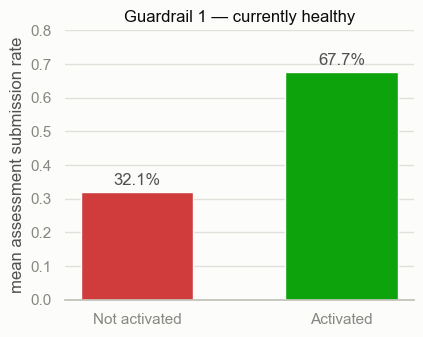

avg score where scored: not activated 68.6, activated 74.3


In [3]:
g1 = m.groupby("activated")[["submission_rate", "avg_score"]].mean()
g1.index = ["Not activated", "Activated"]

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.bar(g1.index, g1["submission_rate"], color=[STATUS["critical"], STATUS["good"]], width=0.55)
for i, v in enumerate(g1["submission_rate"]):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", color="#52514e")
ax.set_ylabel("mean assessment submission rate")
ax.set_title("Guardrail 1 — currently healthy")
ax.set_ylim(0, 0.8)
sns.despine(left=True)
savefig("05_guardrail_submission")
plt.show()

print(f"avg score where scored: not activated {g1.loc['Not activated','avg_score']:.1f}, "
      f"activated {g1.loc['Activated','avg_score']:.1f}")


**[OBS]** Activated enrollments submit at 67.7% vs. 32.1% for non-activated, and average a
higher score where scored (74.3 vs. 68.6). **[HYP] — read with the same caveat as the headline
finding, not as clean independent confirmation.** Non-activated enrollments overlap heavily with
early-withdrawers (notebook 02: 13.7% of "not activated" left within the 14-day window itself),
who mechanically can't submit later assignments regardless of engagement quality. Some of this
gap is the same early-exit pattern showing up a third time, not new evidence. Still directionally
reassuring — no sign of activation being *gamed* by low-value clicking — just not as clean a
guardrail reading as a first pass suggests.

**2. Equity guardrail — activation-rate gap by deprivation band.** Notebook 04's clearest
finding: activation and success both rise with `imd_band` (a UK area-level deprivation index),
a 12.5-point activation gap and 22.4-point success gap, most deprived to least. A team chasing
average activation upward could easily do so entirely by improving outcomes for
already-advantaged students, widening this gap. **This guardrail should move toward zero, not
just stay flat, when the primary metric improves.**

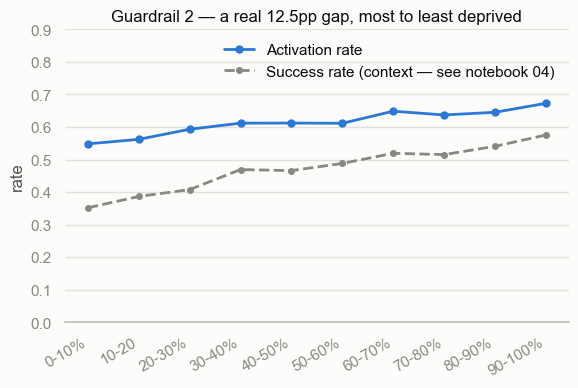

In [4]:
imd_order = ["0-10%", "10-20", "20-30%", "30-40%", "40-50%", "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"]
by_imd = m.groupby("imd_band")[["activated", "success"]].mean().reindex(imd_order)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(range(len(by_imd)), by_imd["activated"], lw=2, marker="o", ms=5, color=CATEGORICAL[0],
        label="Activation rate")
ax.plot(range(len(by_imd)), by_imd["success"], lw=2, ls="--", marker="o", ms=4, color="#898781",
        label="Success rate (context — see notebook 04)")
ax.set_xticks(range(len(by_imd)), by_imd.index, rotation=30, ha="right")
ax.set_ylabel("rate")
ax.set_title("Guardrail 2 — a real 12.5pp gap, most to least deprived")
ax.set_ylim(0, 0.9)
ax.legend(frameon=False)
sns.despine(left=True)
savefig("05_guardrail_equity")
plt.show()

**3. Sustained-engagement guardrail — post-activation decay.** Does "activated" predict lasting
engagement, or just a first burst that a forced onboarding tutorial could fake?

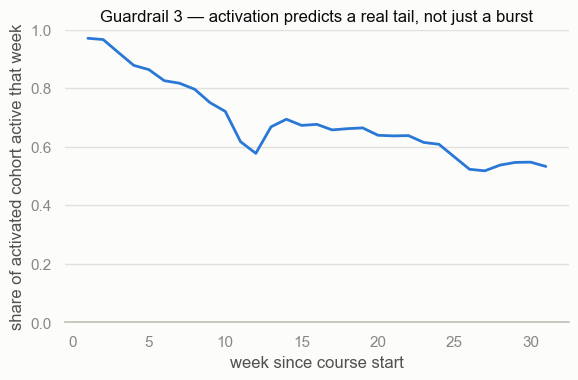

In [5]:
activated_keys = set(map(tuple, m.loc[m["activated"], prep.ENROLL_KEY].values.tolist()))
w = weekly[weekly["clicks"] > 0]
rows = []
for wk in range(1, 32):  # week 1 = days 0-6, no week 0 (see prep.to_display_week)
    ids = set(map(tuple, w.loc[w["week"] == wk, prep.ENROLL_KEY].values.tolist()))
    rows.append({"week": wk, "rate": len(ids & activated_keys) / len(activated_keys)})
decay = pd.DataFrame(rows).set_index("week")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(decay.index, decay["rate"], lw=2, color=CATEGORICAL[0])
ax.set_xlabel("week since course start")
ax.set_ylabel("share of activated cohort active that week")
ax.set_title("Guardrail 3 — activation predicts a real tail, not just a burst")
ax.set_ylim(0, 1)
sns.despine(left=True)
savefig("05_guardrail_decay")
plt.show()


**[OBS]** The activated cohort's weekly active rate declines gradually from ~97% (week 1) to
~53% (week 31) — a real decline, expected over a long course, but not a collapse to near-zero
right after the activation window closes. **[CON]** No "hollow activation" pattern currently —
but this is exactly the guardrail to re-check if activation ever gets directly targeted by an
intervention, since a heavy-handed week-1 push could inflate the metric while producing exactly
that collapse.


## Framework summary

| Role | Metric | Current value | Guards against |
|---|---|---|---|
| **Primary** | Week-2 Activation Rate (≥3 active days in first 14) | **61.7%** | — |
| Guardrail 1 | Assessment submission rate, activated vs. not | 67.7% vs. 32.1% | Activation inflated by low-value clicking |
| Guardrail 2 | Activation-rate gap by deprivation band | 12.5pp (54.8%→67.3%) | Average gains masking a widening equity gap |
| Guardrail 3 | Activated-cohort active rate, week 20+ | ~52-64% | A first-burst-only, unsustained "activation" |


## Synthesis — the project end to end

**[OBS] Data:** OULAD, real, released under a license (Creative Commons Attribution 4.0) that
permits free reuse as long as the source is credited, 32,593 enrollments across 22 course runs —
no monetization stage (education platform), so `final_result` stands in as a labelled
value-outcome proxy throughout, never revenue.

**[OBS] Funnel:** 100% registered → 89.7% ever engage → 61.7% activate → 58.5% submit
≥1 assessment → 37.3% succeed. The two real bottlenecks are never engaging at all and
getting engaged enough to activate; the submission-to-success step is the weakest single
conversion but reflects academic performance, not an engagement gap.

**[CON] Headline finding:** activation (≥3 active days in the first 14) predicts a
24.5-point success lift (exposure-matched, and independently re-verified against a fresh
computation on raw data — the raw, uncorrected figure of 34.8pp partly double-counts early
withdrawal and is not the number used here) and, among the same 14-day-survivor population, a
5.8-point withdrawal reduction (27.7pp unadjusted — most of that gap is the same early-exit
double-count, not a real retention effect), holding within every subject, education level, age
band, credit-load tier, and first-time/repeat split tested — but remains **correlational**, not
proven causal (self-selection: motivation and circumstance plausibly drive both activation and
success).

**[OBS] Equity finding:** feature-usage *mix* is flat across deprivation band; *outcome* is not
— a real 22.4pp success gap and 12.5pp activation gap that holds within every subject. The
mechanism looks more like access/circumstance than platform design, since how engaged students
use the platform doesn't differ by band.

**[OBS] Retention:** withdrawal is front-loaded (44.3% of all withdrawals by week 2, including a
pre-course-withdrawal group); engagement intensity declines gradually even among students who
stay enrolled.

**A data-pipeline bug, caught by independent verification, not by the rigor pass.** The
rigor pass's own adversarial check (excluding students who withdrew within the activation
window) already revised the headline lift down once, from a same-context re-test. A fresh,
independent sub-agent — given only the claim and raw CSVs, no access to this reasoning chain —
then found something the same-context check didn't: the early-window engagement signal
(`prep.build_engagement`) filtered `date < 14` with no lower bound, silently counting pre-course
browsing (negative `date` values) as "first 14 days" activity. This inflated the activation rate
by ~3,700 enrollments. Every number in notebooks 02–05 was recomputed after the fix; the
qualitative finding (a large, disentangled activation effect) survived, but every quoted
percentage changed. Recorded in full in `ADR.md` as the clearest example in this project of what
independent, fresh-context verification catches that same-context review does not.

**A second correction, caught during review, not by either QA layer.** The 27.7pp withdrawal
figure applied the survivor-matching correction to the success lift but not to the parallel
withdrawal comparison — the same mechanical confound (non-activated enrollments that withdrew
*within* the 14-day window, mechanically unable to activate) inflated it too, more severely:
restricted to the same 14-day-survivor population, the real effect is 5.8pp, not 27.7pp. See
notebook 02 and `ADR.md`.

### Recommendations, tied to evidence

1. **Build a week-1 "return" nudge for enrollments with zero activity in week 1.** Justification:
   this is the single steepest point in both the funnel (10.3% never engage at all) and the
   dose-response curve (0→1 active day is the sharpest jump on the whole curve, notebook 02).
   Largest, most tractable population to intervene on early.
2. **Target early support toward enrollments from higher-deprivation bands specifically in the
   first two weeks** — flexible deadlines, faster response, tech-access support — rather than a
   platform feature change, since feature-mix usage doesn't differ by band (notebook 04). Track
   Guardrail 2 explicitly against this intervention.
3. **Before crediting any activation-boosting initiative with the outcome gain, check Guardrails
   1 and 3.** Given the unresolved self-selection confound, a rising activation rate alone is
   not evidence the intervention caused better outcomes — an actual experiment (holdout group)
   would be needed to claim causation.

*A fourth recommendation — nudging lightly-engaged students toward `quiz` specifically — appeared*
*in this notebook's first draft and was retracted during the rigor pass: the underlying*
*correlation didn't survive an exposure-matched re-test (notebook 04) and looks like the same*
*tenure confound as the headline number's raw-vs-corrected gap. Recorded here, not deleted*
*silently, as an AI-assisted-workflow lesson for the ADR — a same-context check alone would*
*plausibly have kept it.*

### Concepts used across this project (consolidated)

Cohort definition under left- vs. right-censoring; rate-vs-mix decomposition (subject
heterogeneity, feature mix vs. volume); disentangling a correlated dimension across 5+
independent splits; funnel as nested AND-conditions; survival/retention-curve construction with
a shared censoring cutoff; dose-response vs. threshold-metric design; chi-square derivation and
why p-values are weak at large n; a primary-metric-plus-guardrails framework; explicit
correlation-vs-causation flagging throughout.

---
**Next:** the README/ADR write-up — the last gate before this project is called finished.